# Walk to Mordor — Exploratory Data Analysis

An investigation of personal walking data spanning three virtual Middle-earth
challenges completed through [The Conqueror](https://www.theconqueror.events/):

| Journey | Character | Period | Target miles |
|---|---|---|---|
| Mordor | Frodo | Mar 2024 – Jan 2025 | 1,815 |
| Return of the King | Aragorn | Jan 2025 – Aug 2025 | 1,482 |
| The Hobbit | Bilbo | Jan 2026 – Jun 2026 | 1,100 |

**Data source:** Google Fit export processed in `etl.ipynb`.  
Only `data/processed/` is read here — no raw health data is loaded.


## 1. Setup

In [1]:
import sys, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
sys.path.insert(0, str(REPO_ROOT / "notebooks"))

from wtm_theme import (apply_theme, JOURNEY_COLORS, CHARACTER_LABEL,
                       JOURNEY_ORDER, UNASSIGNED_COLOR, journey_legend_handles)
apply_theme()

DATA_DIR = REPO_ROOT / "data" / "processed"
daily    = pd.read_csv(DATA_DIR / "daily_steps.csv",  parse_dates=["date"])
journeys = pd.read_csv(DATA_DIR / "journeys.csv",     parse_dates=["start_date", "end_date"])

daily["year"]         = daily["date"].dt.year
daily["month"]        = daily["date"].dt.month
daily["weekday"]      = daily["date"].dt.dayofweek    # 0 = Mon
daily["weekday_name"] = daily["date"].dt.day_name()

print(f"Daily rows : {len(daily):,}   ({daily['date'].min().date()} → {daily['date'].max().date()})")
print(f"Segments   : {len(journeys)}")
print(f"Challenge-assigned days : {daily['journey_id'].notna().sum():,}")


Daily rows : 806   (2024-03-27 → 2026-06-10)
Segments   : 11
Challenge-assigned days : 628


## 2. At a Glance

Before examining the detail, here is a one-table summary of the three challenges.


In [2]:
rows = []
for jid in JOURNEY_ORDER:
    jd   = daily[daily["journey_id"] == jid]
    segs = journeys[journeys["journey_id"] == jid]
    char = jd["character"].dropna().iloc[0]
    start, end = segs["start_date"].min(), segs["end_date"].max()
    rows.append({
        "Character":       char,
        "Period":          f"{start.strftime('%b %Y')} – {end.strftime('%b %Y')}",
        "Calendar days":   (end - start).days + 1,
        "Active days":     len(jd),
        "Total miles":     round(jd["distance_miles"].sum(), 1),
        "Target miles":    segs["target_miles"].sum(),
        "vs target":       f"{jd['distance_miles'].sum() / segs['target_miles'].sum() * 100:.1f}%",
        "Avg mi/day":      round(jd["distance_miles"].mean(), 2),
        "Median mi/day":   round(jd["distance_miles"].median(), 2),
        "Peak day (mi)":   round(jd["distance_miles"].max(), 2),
    })

summary = pd.DataFrame(rows).set_index("Character")
display(summary.T)


Character,Frodo,Aragorn,Bilbo
Period,Mar 2024 – Jan 2025,Jan 2025 – Aug 2025,Jan 2026 – Jun 2026
Calendar days,287,225,142
Active days,261,225,142
Total miles,1823.0,1493.5,1148.1
Target miles,1815,1482,1100
vs target,100.4%,100.8%,104.4%
Avg mi/day,6.98,6.64,8.09
Median mi/day,7.12,6.49,7.93
Peak day (mi),17.37,16.72,16.43


All three journeys **exceeded** their Conqueror target distances.

Bilbo's 142-day journey stands apart: the highest average (8.09 mi/day) and the
highest median (7.93 mi/day) of the three, despite covering the least total
mileage. In roughly half the calendar time of Frodo's challenge, Bilbo covered
more than 60% of the same distance — a sustained, compressed effort.

Frodo's 261 active days span the broadest range of conditions: from a winter
start, through summer, through the 27-day challenge pause, and into the new
year — and still ended 8 miles over target.

Across all three challenges: roughly **4,465 miles** of walking assigned to a
challenge segment, and **5,196 miles** total across the full project window
including gap periods.


## 3. Daily Activity Over Time

The complete daily record coloured by challenge period.  
A 14-day centred rolling average reveals the underlying pace.


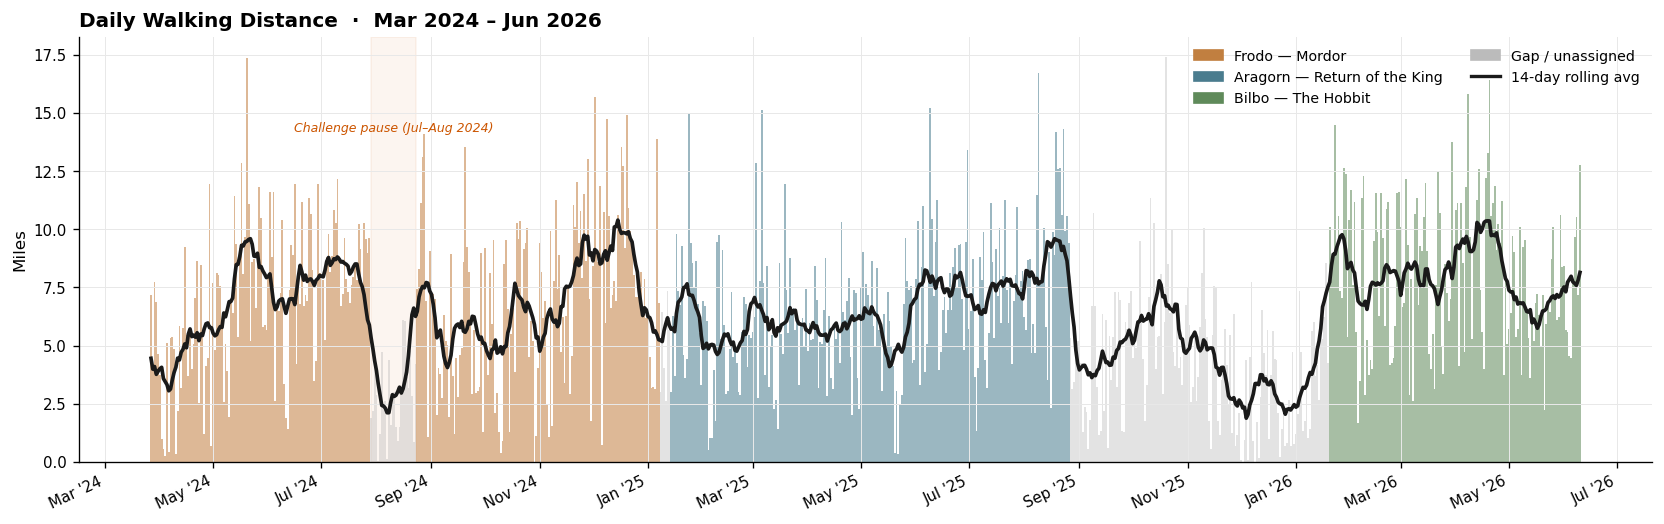

In [3]:
ds = daily.sort_values("date").copy()
roll = (
    ds.set_index("date")["distance_miles"]
    .rolling("14D", center=True, min_periods=7)
    .mean()
    .reset_index(name="roll14")
)
ds = ds.merge(roll, on="date", how="left")

fig, ax = plt.subplots(figsize=(14, 4.5))

for jid in JOURNEY_ORDER:
    m = ds["journey_id"] == jid
    ax.bar(ds.loc[m, "date"], ds.loc[m, "distance_miles"],
           color=JOURNEY_COLORS[jid], alpha=0.55, width=1, linewidth=0)

m_na = ds["journey_id"].isna()
ax.bar(ds.loc[m_na, "date"], ds.loc[m_na, "distance_miles"],
       color=UNASSIGNED_COLOR, alpha=0.4, width=1, linewidth=0)

ax.plot(ds["date"], ds["roll14"], color="#1A1A1A", lw=2.2, zorder=5)

# Frodo challenge-pause annotation
pause_s, pause_e = pd.Timestamp("2024-07-29"), pd.Timestamp("2024-08-23")
ax.axvspan(pause_s, pause_e, alpha=0.06, color="#CC5500", zorder=0)
mid_p = pause_s + (pause_e - pause_s) / 2
ax.text(mid_p, 14.2, "Challenge pause (Jul\u2013Aug 2024)",
        fontsize=7.5, color="#CC5500", ha="center", style="italic")

ax.set_ylabel("Miles")
ax.set_ylim(bottom=0)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate(rotation=25, ha="right")
ax.set_title("Daily Walking Distance  \u00b7  Mar 2024 \u2013 Jun 2026", loc="left")

handles = journey_legend_handles(include_unassigned=True) + [
    Line2D([0], [0], color="#1A1A1A", lw=2, label="14-day rolling avg"),
]
ax.legend(handles=handles, loc="upper right", ncol=2, fontsize=8.5)
fig.tight_layout()
plt.show()

The rolling average sits broadly in the **6–9 miles/day** band across all three
challenges, with no obvious multi-week collapse in pace. What variation exists
tends to be short-lived: a dip below 5 miles followed by a recovery within days.

The annotated **challenge pause** between *Mines of Moria* and *The Eye of
Sauron* (grey bars, July–August 2024) shows that walking continued uninterrupted
during those 27 days — the pause was in the challenge app, not in the walking
itself.

The two large grey clusters — Jan 2025 (between Frodo and Aragorn) and
Aug 2025 – Jan 2026 (between Aragorn and Bilbo) — are inter-journey gaps.
The second of these spans 147 days and 730+ miles walked with no active
challenge: the habit clearly did not depend on the external structure.


## 4. Calendar View

A GitHub-style activity calendar for each year of the project.  
Colour intensity represents daily mileage; grey cells are low- or zero-activity
days; white cells have no data (outside the project window or before/after the
export range).


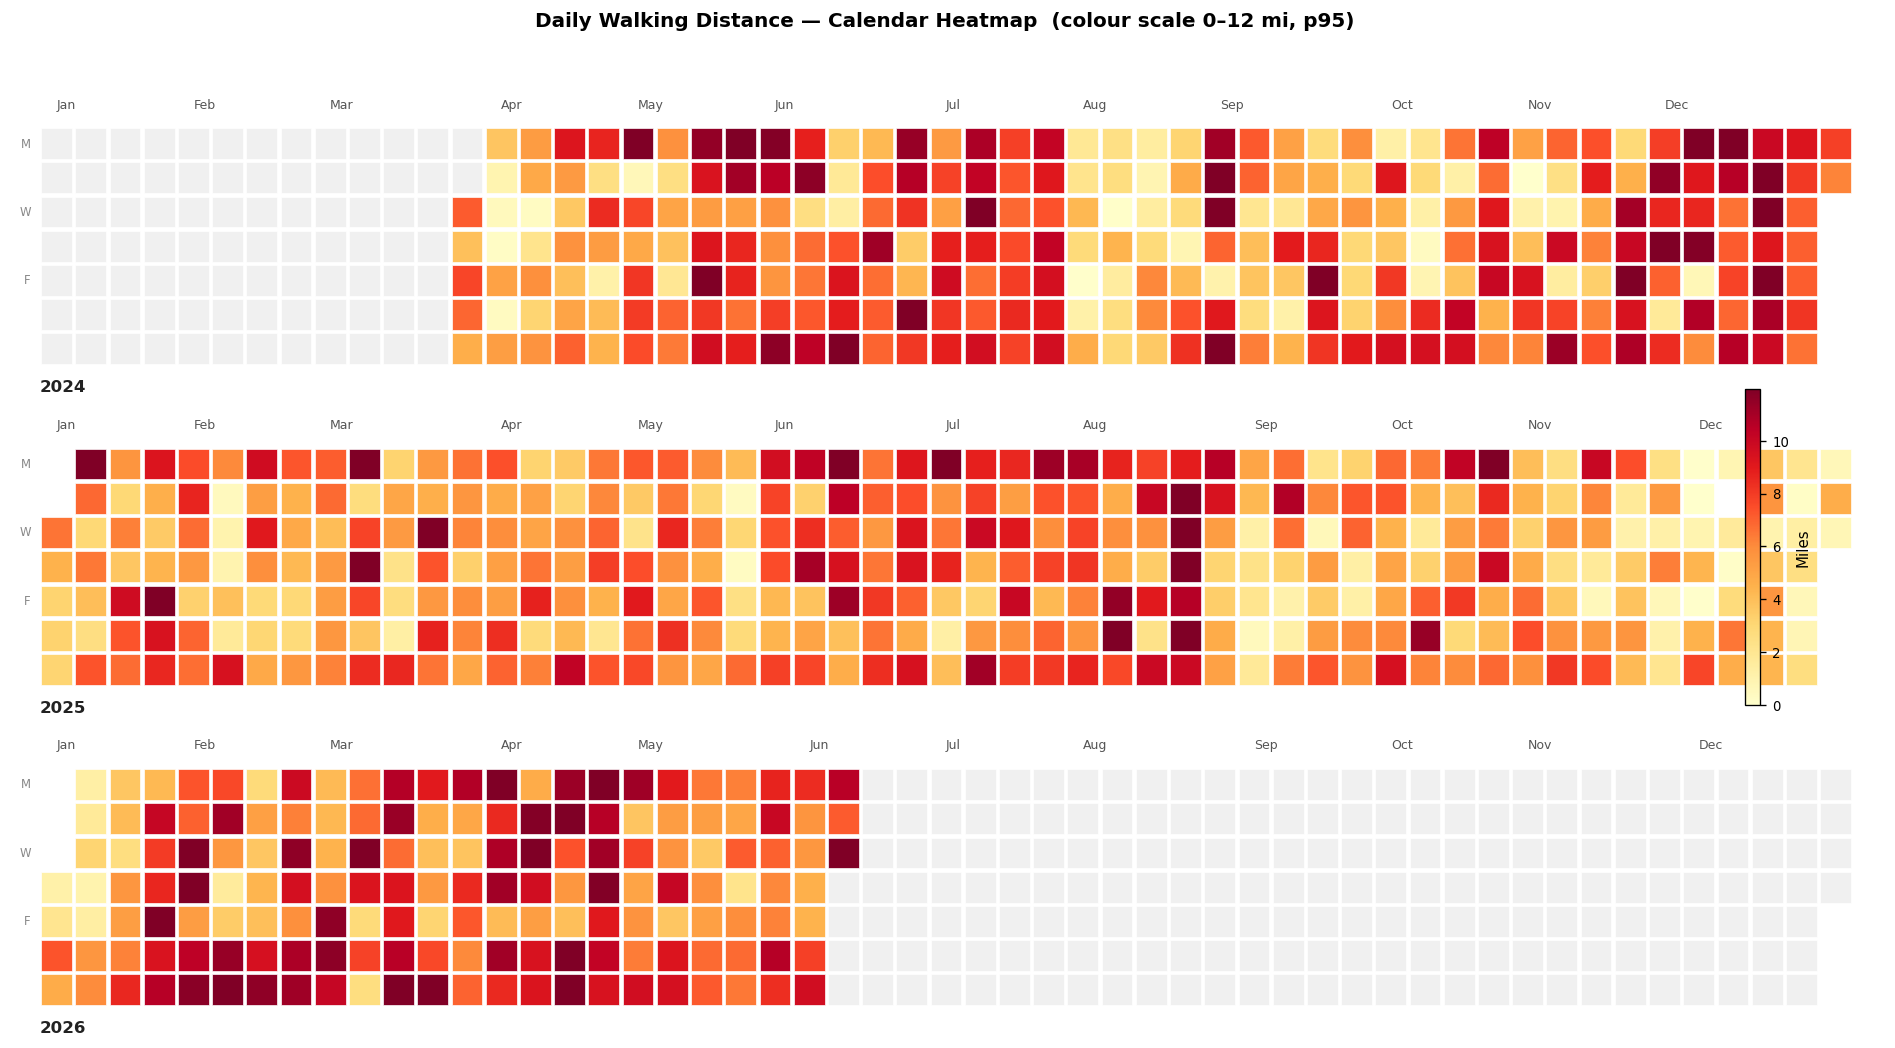

In [4]:
def draw_year_calendar(ax, date_val_map, year, vmax, cmap="YlOrRd"):
    """GitHub-contribution-style heatmap for one calendar year."""
    jan1      = datetime.date(year, 1, 1)
    is_leap   = year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)
    n_days    = 366 if is_leap else 365
    start_dow = jan1.weekday()                     # 0 = Monday
    n_weeks   = (n_days + start_dow + 6) // 7

    grid      = np.full((7, n_weeks), np.nan)
    month_col: dict[str, int] = {}

    for offset in range(n_days):
        d   = jan1 + datetime.timedelta(days=offset)
        pos = offset + start_dow
        col, row = divmod(pos, 7)
        grid[row, col] = date_val_map.get(d, 0.0)
        if d.day == 1:
            month_col[d.strftime("%b")] = col

    cmap_obj = plt.cm.get_cmap(cmap)
    norm     = mcolors.Normalize(vmin=0, vmax=vmax)

    for col in range(n_weeks):
        for row in range(7):
            val = grid[row, col]
            if np.isnan(val):
                continue
            fc = "#F0F0F0" if val == 0 else cmap_obj(norm(val))
            ax.add_patch(mpatches.Rectangle(
                (col - 0.45, row - 0.45), 0.90, 0.90,
                fc=fc, ec="white", linewidth=0.4, zorder=2,
            ))

    for month_name, col in month_col.items():
        ax.text(col, -0.95, month_name, fontsize=7.5, ha="left",
                va="bottom", color="#555555")

    for i, (lbl, show) in enumerate(
        zip(["M", "T", "W", "T", "F", "S", "S"],
            [True, False, True, False, True, False, False])
    ):
        if show:
            ax.text(-0.75, i, lbl, fontsize=7, ha="right",
                    va="center", color="#888888")

    ax.set_xlim(-1.3, n_weeks + 0.4)
    ax.set_ylim(6.75, -1.55)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.text(-0.5, 7.35, str(year), fontsize=10, fontweight="bold",
            color="#222222", ha="left", va="bottom")


date_dist_map = dict(zip(daily["date"].dt.date, daily["distance_miles"]))
vmax_cal = float(daily["distance_miles"].quantile(0.95))

fig, axes = plt.subplots(3, 1, figsize=(17, 8.5))
for ax, year in zip(axes, [2024, 2025, 2026]):
    draw_year_calendar(ax, date_dist_map, year, vmax_cal)

sm   = plt.cm.ScalarMappable(cmap="YlOrRd",
                              norm=mcolors.Normalize(vmin=0, vmax=vmax_cal))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical",
                    fraction=0.01, pad=0.01, shrink=0.85)
cbar.set_label("Miles", fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.suptitle("Daily Walking Distance — Calendar Heatmap  "
             f"(colour scale 0–{vmax_cal:.0f} mi, p95)",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout(rect=[0, 0, 0.97, 1])
plt.show()


Three observations from the calendar:

**Near-continuous activity.** There are almost no completely light (≤ 1 mile)
cells across three years — the walking habit was genuinely daily rather than
episodic.

**The Aragorn–Bilbo gap (Sep 2025 – Jan 2026)** is the most visible quiet
period. Even so, the cells are not white — they show moderate activity throughout,
confirming that the inter-journey period was not a rest period.

**2026 stands out.** The Bilbo period (Jan–Jun 2026) shows a consistently dark
band across all six months — both evidence of the higher average pace and of the
125-day unbroken streak that spans almost the entire Hobbit challenge period.


## 5. Accumulated Distance

Total walking miles accumulated day by day.  
Dot colour shows which challenge was active; grey indicates gap or
unassigned days. The slope reflects pace.


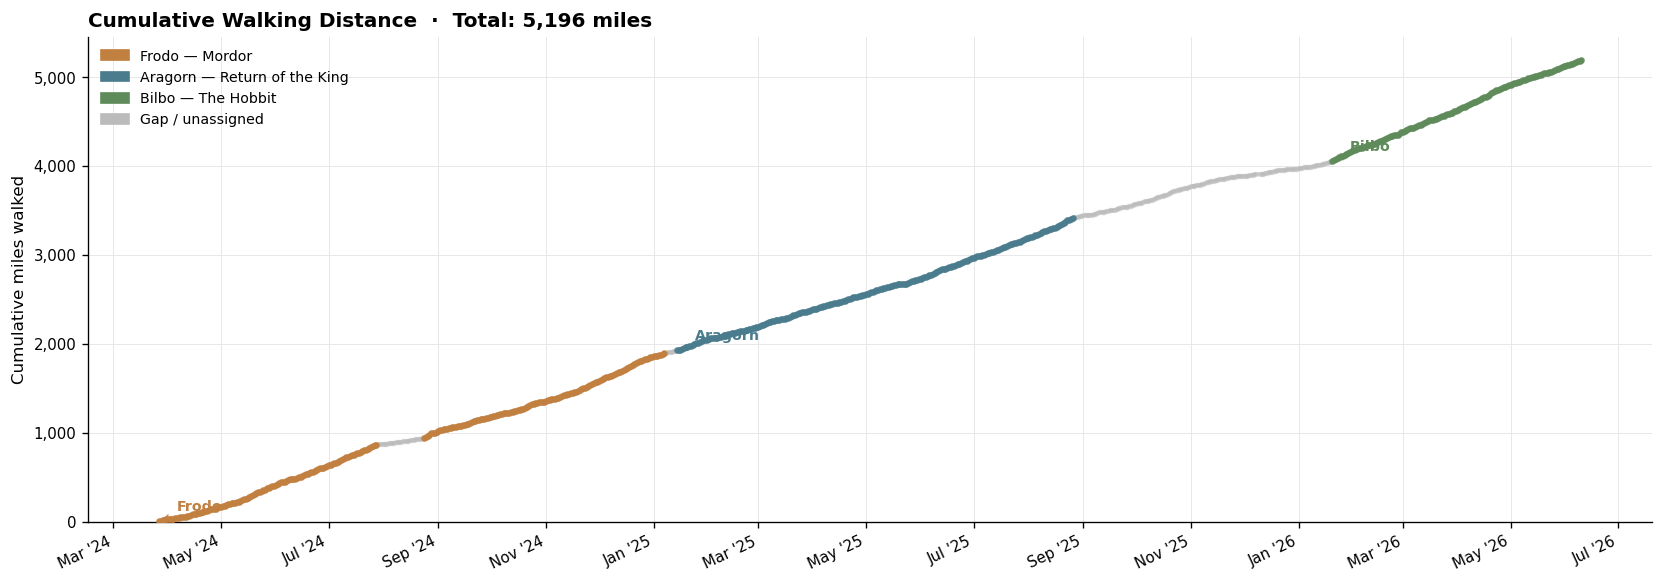

In [5]:
ds = daily.sort_values("date").copy()
ds["cum_miles"] = ds["distance_miles"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ds["date"], ds["cum_miles"], color="#E0E0E0", lw=2, zorder=1)

for jid in JOURNEY_ORDER:
    m = ds["journey_id"] == jid
    ax.scatter(ds.loc[m, "date"], ds.loc[m, "cum_miles"],
               c=JOURNEY_COLORS[jid], s=9, zorder=4, alpha=0.85)

m_na = ds["journey_id"].isna()
ax.scatter(ds.loc[m_na, "date"], ds.loc[m_na, "cum_miles"],
           c=UNASSIGNED_COLOR, s=5, zorder=3, alpha=0.45)

# Annotate each challenge start
for jid in JOURNEY_ORDER:
    segs  = journeys[journeys["journey_id"] == jid]
    j_start = segs["start_date"].min()
    row = ds[ds["date"] == j_start]
    if len(row):
        cum_val = row["cum_miles"].values[0]
        char = CHARACTER_LABEL[jid].split("—")[0].strip()
        ax.annotate(
            char,
            xy=(j_start, cum_val),
            xytext=(j_start + pd.Timedelta(days=10), cum_val + 120),
            fontsize=8.5, color=JOURNEY_COLORS[jid], fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=JOURNEY_COLORS[jid], lw=0.8),
        )

total_end = ds["cum_miles"].iloc[-1]
ax.set_ylabel("Cumulative miles walked")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate(rotation=25, ha="right")
ax.set_title(f"Cumulative Walking Distance  ·  Total: {total_end:,.0f} miles", loc="left")

handles = journey_legend_handles(include_unassigned=True)
ax.legend(handles=handles, loc="upper left", markerscale=2, fontsize=8.5)
fig.tight_layout()
plt.show()


The cumulative chart reaches roughly **5,200 miles** by the end of the Bilbo
challenge — a figure that includes 730+ miles walked during gap periods between
challenges.

Two slope signatures stand out:

- **The Bilbo section** (far right, green) has the steepest gradient, consistent
  with the highest daily average of the three challenges.
- **The Aragorn–Bilbo gap** (long grey stretch, Aug 2025 – Jan 2026) continues
  accumulating at a steady ~4 miles/day across 147 days — slower than the
  challenge pace, but never stopping.

The absence of any truly flat section confirms what the calendar showed: this was
a walking habit, not a challenge-driven burst.


## 6. How Do the Three Journeys Compare?

Key metrics side by side.


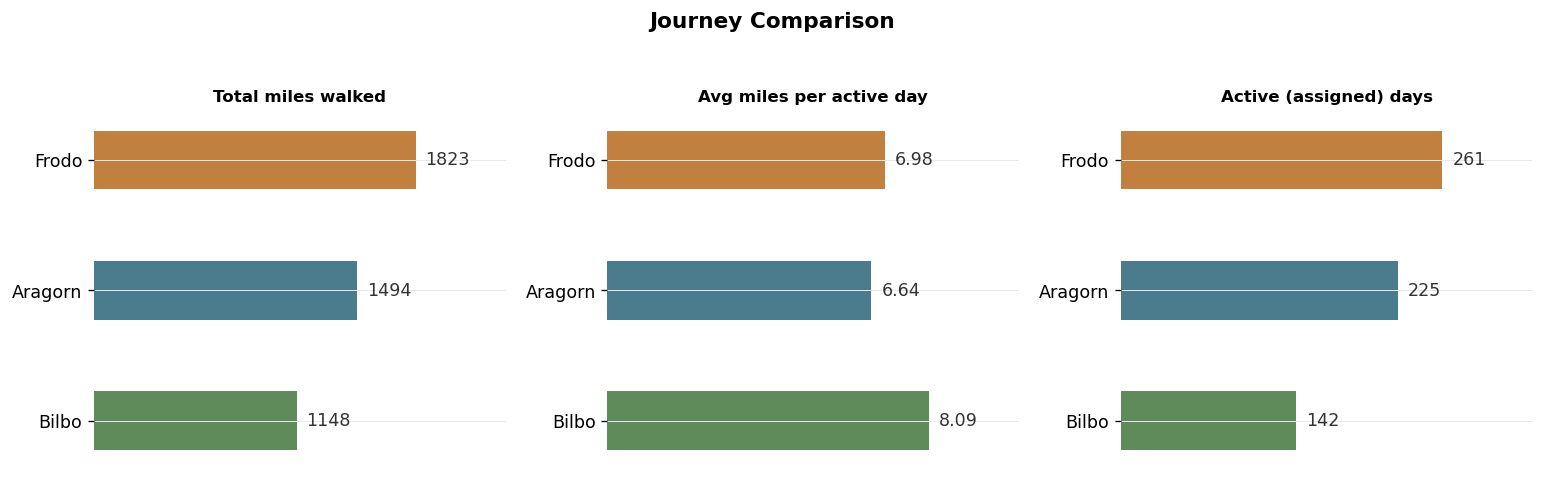

In [6]:
comp = {}
for jid in JOURNEY_ORDER:
    jd   = daily[daily["journey_id"] == jid]
    segs = journeys[journeys["journey_id"] == jid]
    comp[jid] = {
        "char":          jd["character"].dropna().iloc[0],
        "total_miles":   jd["distance_miles"].sum(),
        "active_days":   len(jd),
        "avg_mi_day":    jd["distance_miles"].mean(),
        "median_mi_day": jd["distance_miles"].median(),
        "peak_mi":       jd["distance_miles"].max(),
        "target_miles":  segs["target_miles"].sum(),
        "cal_days":      (segs["end_date"].max() - segs["start_date"].min()).days + 1,
    }

chars  = [comp[jid]["char"] for jid in JOURNEY_ORDER]
colors = [JOURNEY_COLORS[jid] for jid in JOURNEY_ORDER]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

metrics = [
    ("total_miles",   "Total miles walked",       "{:.0f}"),
    ("avg_mi_day",    "Avg miles per active day",  "{:.2f}"),
    ("active_days",   "Active (assigned) days",    "{:.0f}"),
]
for ax, (col, title, fmt) in zip(axes, metrics):
    vals = [comp[jid][col] for jid in JOURNEY_ORDER]
    bars = ax.barh(chars, vals, color=colors, height=0.45, edgecolor="none")
    ax.bar_label(bars, labels=[fmt.format(v) for v in vals],
                 padding=6, fontsize=10.5, color="#333333")
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlim(0, max(vals) * 1.28)
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", labelsize=10.5)

fig.suptitle("Journey Comparison", fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout()
plt.show()


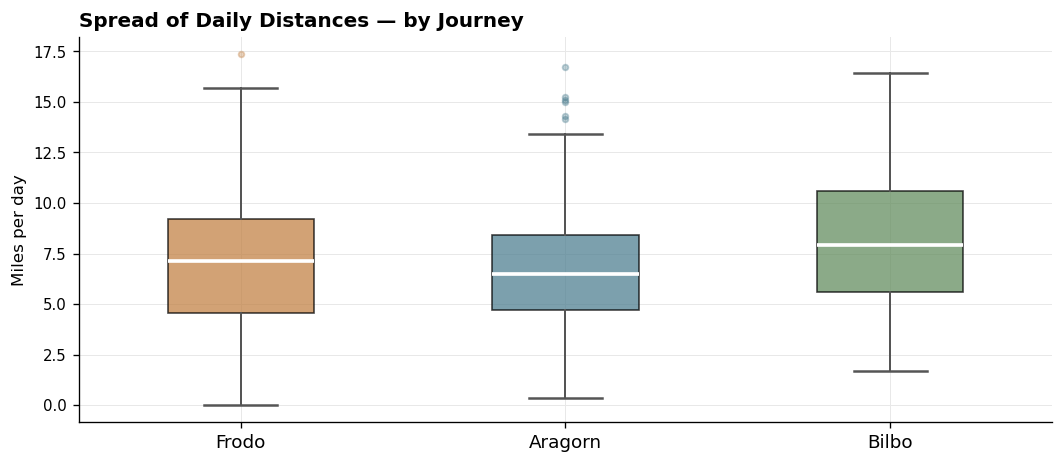

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

data_by_journey = [
    daily.loc[daily["journey_id"] == jid, "distance_miles"].values
    for jid in JOURNEY_ORDER
]
bp = ax.boxplot(
    data_by_journey,
    vert=True,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color="white", lw=2.2),
    whiskerprops=dict(lw=1.2, color="#555555"),
    capprops=dict(lw=1.5, color="#555555"),
    flierprops=dict(marker="o", markersize=3.5, alpha=0.35),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.72)
for flier, color in zip(bp["fliers"], colors):
    flier.set(markerfacecolor=color, markeredgecolor=color)

ax.set_xticklabels(chars, fontsize=11)
ax.set_ylabel("Miles per day")
ax.set_title("Spread of Daily Distances — by Journey", loc="left")
fig.tight_layout()
plt.show()


**Frodo** shows the widest spread: the most days below 2 miles (9.2% of
assigned days) but also the highest single-day peak (17.37 mi). His journey's
length — 261 days across multiple seasons — naturally accommodated more
variability.

**Aragorn** has the tightest box. The interquartile range is narrower than
either other journey and the median of 6.49 mi/day sits below Frodo's 7.12 and
Bilbo's 7.93. His walking was the most consistent and the least prone to
outliers in either direction.

**Bilbo** sits highest overall: median 7.93, mean 8.09, and only 1 day in 142
fell below 2 miles. The Hobbit challenge was clearly approached with intensity
from the outset.


## 7. Distribution of Daily Distances

What does a typical challenge day look like across the three journeys?


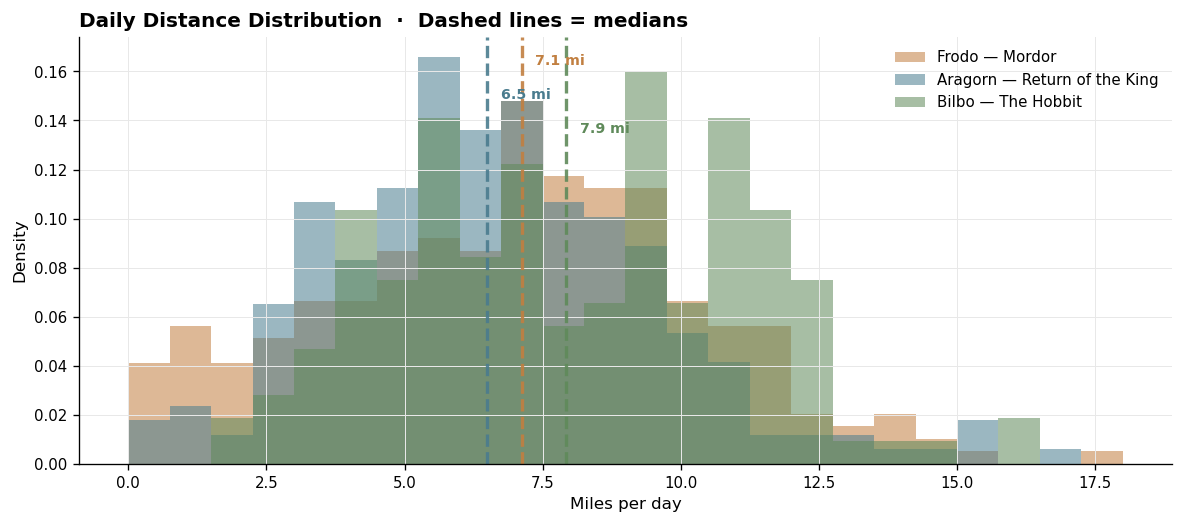

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.arange(0, daily["distance_miles"].max() + 1.0, 0.75)

for jid in JOURNEY_ORDER:
    jd = daily.loc[daily["journey_id"] == jid, "distance_miles"]
    ax.hist(jd, bins=bins, density=True, alpha=0.55,
            color=JOURNEY_COLORS[jid], label=CHARACTER_LABEL[jid],
            histtype="stepfilled", linewidth=0)

# Staggered median lines to avoid label overlap
y_offsets = [0.96, 0.88, 0.80]
for jid, y_frac in zip(JOURNEY_ORDER, y_offsets):
    med = daily.loc[daily["journey_id"] == jid, "distance_miles"].median()
    ax.axvline(med, color=JOURNEY_COLORS[jid], lw=2, ls="--", alpha=0.9)
    ax.text(med + 0.25, ax.get_ylim()[1] * y_frac,
            f"{med:.1f} mi",
            fontsize=8.5, color=JOURNEY_COLORS[jid],
            va="top", fontweight="bold")

ax.set_xlabel("Miles per day")
ax.set_ylabel("Density")
ax.set_title("Daily Distance Distribution  \u00b7  Dashed lines = medians", loc="left")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

All three journeys share the same general shape: roughly unimodal, centred
between 6 and 9 miles, with a right-hand tail extending to 15+ miles and a
smaller left-side cluster of lower-distance days.

This distribution does not look like someone walking a fixed daily target.
It looks like a person with an active daily life whose walking naturally varies —
accumulating distance in stretches of 8–12 mile days punctuated by lighter
days, rather than hitting a steady 7.0 miles every morning.

The left cluster (below 3 miles) deserves a note: Google Fit records any
detectable movement, so these low-distance days likely represent days when
the phone was carried but little deliberate walking occurred — the data
does not contain a single true zero-step day.


## 8. Temporal Patterns

Does walking behaviour vary by day of the week or by month?


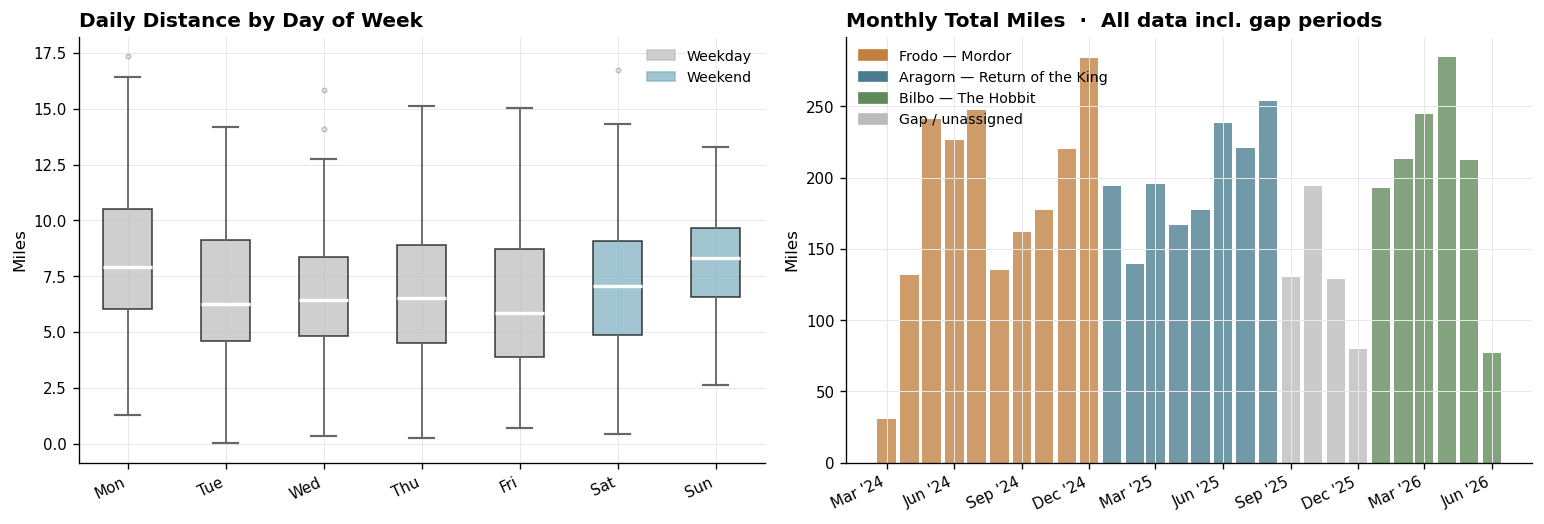

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Day-of-week box plots ──────────────────────────────────────────────────
ax = axes[0]
day_order  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
short_days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
jdays      = daily[daily["journey_id"].notna()]
dow_data   = [jdays.loc[jdays["weekday_name"] == d, "distance_miles"].values
              for d in day_order]
wknd_color, wkday_color = "#7AAFC0", "#BBBBBB"
bp = ax.boxplot(
    dow_data, vert=True, patch_artist=True, widths=0.5,
    medianprops=dict(color="white", lw=2),
    whiskerprops=dict(lw=1.1, color="#666666"),
    capprops=dict(lw=1.3, color="#666666"),
    flierprops=dict(marker="o", markersize=2.5, alpha=0.25, color="#888888"),
)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(wknd_color if i >= 5 else wkday_color)
    patch.set_alpha(0.70)

ax.set_xticklabels(short_days, fontsize=9)
ax.set_ylabel("Miles")
ax.set_title("Daily Distance by Day of Week", loc="left")
ax.legend(handles=[
    mpatches.Patch(color=wkday_color, alpha=0.7, label="Weekday"),
    mpatches.Patch(color=wknd_color,  alpha=0.7, label="Weekend"),
], fontsize=8.5)

# ── Monthly totals (all months in project range) ───────────────────────────
ax = axes[1]
monthly = (
    daily.groupby(["year", "month"])["distance_miles"]
    .sum()
    .reset_index()
)
monthly["dt"] = pd.to_datetime(monthly[["year","month"]].assign(day=1))

def month_color(year, month):
    m = daily[(daily["date"].dt.year == year) & (daily["date"].dt.month == month)]
    counts = m.groupby("journey_id").size()
    if counts.empty:
        return UNASSIGNED_COLOR
    return JOURNEY_COLORS.get(str(counts.idxmax()), UNASSIGNED_COLOR)

monthly["color"] = monthly.apply(
    lambda r: month_color(int(r["year"]), int(r["month"])), axis=1
)
ax.bar(monthly["dt"], monthly["distance_miles"],
       color=monthly["color"], alpha=0.78, width=25, edgecolor="none")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=25, ha="right", which="both")
ax.set_ylabel("Miles")
ax.set_title("Monthly Total Miles  ·  All data incl. gap periods", loc="left")
handles = journey_legend_handles(include_unassigned=True)
ax.legend(handles=handles, fontsize=8.5, loc="upper left")

fig.tight_layout()
plt.show()


**Day of week:** Sunday and Monday produce the highest medians (8.33 and 7.93
miles respectively); Friday the lowest (5.85 miles). The weekend uptick is
modest but consistent — likely reflecting longer walks when unstructured time
is available. The Friday dip may reflect end-of-week fatigue or early finishes
cutting into afternoon walking time.

What's notable is the *absence* of a dramatic pattern: the medians range only
from ~5.9 to 8.3 miles across all seven days. This is not a weekend-warrior
profile — it is a daily walker with slight weekend preference.

**Monthly totals:** Monthly accumulated mileage is broadly even across all
three challenge periods, with no seasonal collapse. The long grey bar in the
Sep 2025 – Jan 2026 window reflects the Aragorn–Bilbo inter-journey gap:
lower monthly totals than challenge months, but persistent.


## 9. Walking Streaks

An unbroken streak of meaningful walking days, using a 2-mile threshold
to filter incidental phone-pocket movement.


In [10]:
THRESH = 2.0

ds2 = daily.sort_values("date").copy()
ds2["active"] = ds2["distance_miles"] >= THRESH
ds2["sg"]     = (ds2["active"] != ds2["active"].shift()).cumsum()

streaks = (
    ds2.groupby("sg")
    .agg(active=("active","first"),
         start=("date","first"),
         end=("date","last"),
         days=("date","count"),
         total=("distance_miles","sum"))
    .query("active == True")
    .sort_values("days", ascending=False)
    .reset_index(drop=True)
)
streaks["start"] = streaks["start"].dt.date
streaks["end"]   = streaks["end"].dt.date
streaks["total"] = streaks["total"].round(1)
streaks["avg"]   = (streaks["total"] / streaks["days"]).round(2)

print(f"Total days with ≥ {THRESH} mi : {ds2['active'].sum():,}  of  {len(ds2):,} in project range")
print(f"Total break days             : {(~ds2['active']).sum()}")
print()
print("Top 8 streaks:")
print(streaks.head(8)[["start","end","days","total","avg"]].to_string(index=False))


Total days with ≥ 2.0 mi : 728  of  806 in project range
Total break days             : 78

Top 8 streaks:
     start        end  days  total  avg
2026-02-06 2026-06-10   125  994.0 7.95
2025-03-16 2025-05-19    65  392.5 6.04
2025-07-06 2025-09-02    59  457.9 7.76
2024-12-07 2025-02-03    59  443.3 7.51
2024-06-13 2024-07-28    46  385.0 8.37
2025-05-23 2025-07-04    43  316.2 7.35
2025-10-09 2025-11-12    35  217.8 6.22
2025-02-09 2025-03-14    34  200.2 5.89


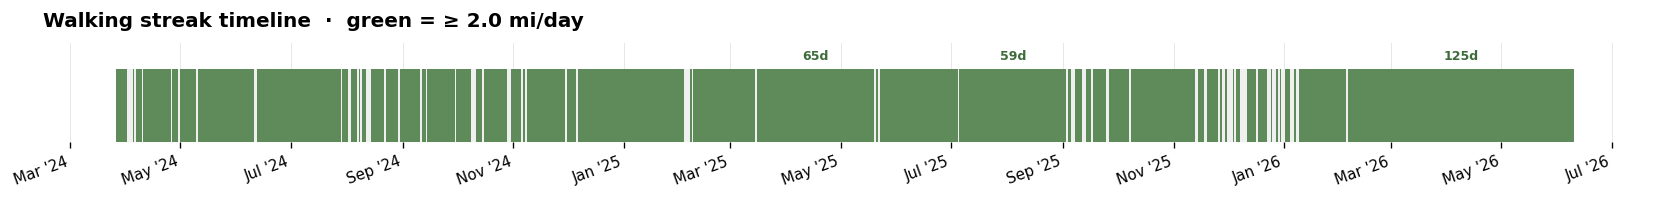

In [11]:
# Visual streak timeline
fig, ax = plt.subplots(figsize=(14, 1.8))

for _, row in ds2.iterrows():
    color = "#5F8A5A" if row["active"] else "#F0F0F0"
    ax.bar(row["date"], 1, width=1, color=color, linewidth=0, zorder=2)

# Annotate the 3 longest streaks
for _, s in streaks.head(3).iterrows():
    mid = pd.Timestamp(s["start"]) + (pd.Timestamp(s["end"]) - pd.Timestamp(s["start"])) / 2
    ax.text(mid, 1.08, f"{s['days']}d",
            fontsize=7.5, ha="center", va="bottom", color="#3D6B3A",
            fontweight="bold")

ax.set_ylim(0, 1.35)
ax.set_yticks([])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate(rotation=20, ha="right")
ax.set_title(f"Walking streak timeline  ·  green = ≥ {THRESH} mi/day", loc="left", pad=10)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

fig.tight_layout()
plt.show()


The longest unbroken streak is **125 consecutive days** (Feb–Jun 2026),
spanning the entire Bilbo challenge and the weeks leading into it — an average
of 7.95 miles/day with never a day below 2 miles.

The second and third longest (65 days and 59 days) both fall within Aragorn's
journey, reinforcing his challenge as the most consistent of the three.

Across all 806 project days, **728 (90.3%) exceeded the 2-mile threshold** — only
78 break days in over two years. The timeline is almost entirely green. The white
gaps cluster in the transition zones between challenges and in the early months
of the Aragorn–Bilbo gap; once any given challenge period is underway, breaks are
extremely rare.

---

## Key Findings

| # | Finding |
|---|---|
| 1 | **~5,196 total miles** across the full project window; **~4,465 miles** during challenge segments. |
| 2 | **All three challenges exceeded their target distances.** Frodo +0.4%, Aragorn +0.8%, Bilbo +4.4%. |
| 3 | **Bilbo's journey was the most intense** — highest average (8.09 mi/day) and median (7.93 mi/day) with only 1 sub-2-mile day in 142. |
| 4 | **Aragorn's journey was the most consistent** — tightest IQR of daily distances; 3 of the 8 longest streaks fall within his challenge period. |
| 5 | **The Frodo challenge pause is invisible in the walking data.** 26 days of walking continued uninterrupted during the Jul–Aug 2024 gap. |
| 6 | **The Aragorn–Bilbo inter-journey gap (147 days) produced 730+ miles.** The habit did not depend on an active challenge. |
| 7 | **Sunday and Monday are the longest walking days** (medians 8.33 and 7.93 mi); Friday the shortest (5.85 mi). The pattern is mild — this is a daily walker, not a weekend athlete. |
| 8 | **728 of 806 project days (90.3%) exceeded 2 miles.** Only 78 break days in over two years. Longest unbroken streak: **125 days** (Feb–Jun 2026). |
| 9 | **No true zero-step days** in the processed dataset — Google Fit recorded some movement every single day. |
| 10 | **Daily distances follow a right-skewed unimodal distribution** centred ~7 miles, with a meaningful left tail of low-distance days and an upper tail reaching 17+ miles. |

*These findings provide the analytical foundation for the narrative layer of the
GitHub Pages visualisation.*